In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
data = {
    'CustomerID': np.arange(1, 101),
    'Age': np.random.randint(18, 65, size=100),
    'Average_Spend': np.random.uniform(5, 50, size=100),
    'Visits_per_Week': np.random.uniform(1, 7, size=100),
    'Promotion_Interest': np.random.randint(1, 11, size=100)
}

df = pd.DataFrame(data)
df.head()

,CustomerID,Age,Average_Spend,Visits_per_Week,Promotion_Interest
0,1,56,18.206968,5.266897,2
1,2,46,5.633592,5.857006,9
2,3,32,13.947908,3.091996,8
3,4,60,37.010388,1.577059,10
4,5,25,40.557899,6.643140,7


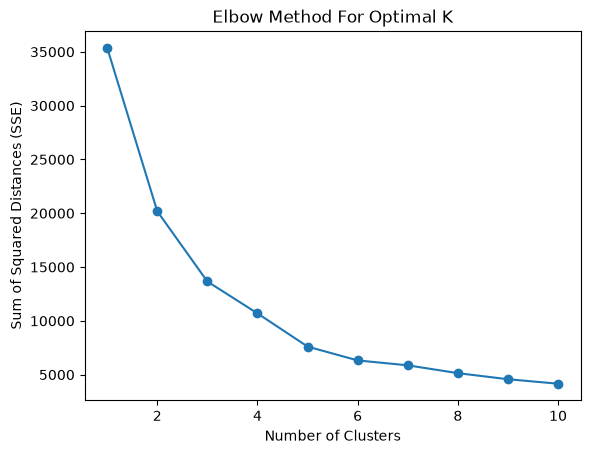

In [3]:
X = df[['Age', 'Average_Spend', 'Visits_per_Week', 'Promotion_Interest']]

sse = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.title('Elbow Method For Optimal K')
plt.show()

In [4]:
features = X = df[['Age', 'Average_Spend', 'Visits_per_Week', 'Promotion_Interest']]

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(features)

cluster_names = {0: 'Daily', 1: 'Promotion', 2:'Weekend'}
df['Customer Group'] = df['Cluster'].map(cluster_names)

df.head()

,CustomerID,Age,Average_Spend,Visits_per_Week,Promotion_Interest,Cluster,Customer Group
0,1,56,18.206968,5.266897,2,2,Weekend
1,2,46,5.633592,5.857006,9,2,Weekend
2,3,32,13.947908,3.091996,8,2,Weekend
3,4,60,37.010388,1.577059,10,0,Daily
4,5,25,40.557899,6.643140,7,1,Promotion


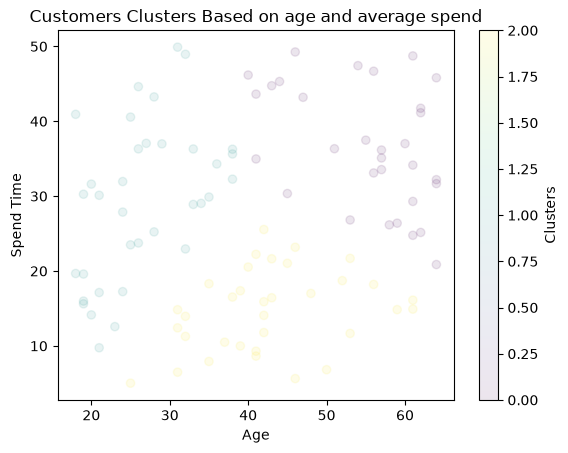

In [5]:
plt.scatter(df['Age'], df['Average_Spend'], c=df['Cluster'], cmap='viridis', marker='o', alpha=0.1)
plt.xlabel('Age')

plt.ylabel('Spend Time')
plt.title('Customers Clusters Based on age and average spend')
plt.colorbar(label='Clusters')
plt.show()

In [6]:
print(silhouette_score(features, df['Cluster']))

0.36846369703368004


In [7]:
import pickle

In [8]:
pickle.dump(kmeans, open('kmeans.pkl', 'wb'))

In [9]:
kmeans = pickle.load(open('kmeans.pkl', 'rb'))

In [10]:
def clustering(age, avg_spend, visit_per_week, promotion_interest):
    new_customer = np.array([[age, avg_spend, visit_per_week, promotion_interest]])
    predicted_cluster = kmeans.predict(new_customer)

    if predicted_cluster[0] == 0:
        return 'Daily'
    elif predicted_cluster == 1:
        return 'Weekend'
    else:
        return 'Promotion'

In [12]:
age = 41
avg_spend = 40
visit_per_week = 4
promotion_interest = 9

predicted_cluster = clustering(age, avg_spend, visit_per_week, promotion_interest)

print("new customer assigned to cluster: ", predicted_cluster)

new customer assigned to cluster:  Daily


/home/dimeji/Machine_Learning_Lab/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
